In [1]:
# Cell 1 – Imports & paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

import joblib

# Paths
FEATURE_FILE = r"D:\emotion-drift-project\data\eyet4empathy_features_labeled.csv"
MODEL_SAVE   = r"D:\emotion-drift-project\data\rf_model_best.joblib"

print("Final model training started")

Final model training started


In [10]:
# Cell 2 – Load & prepare data

df = pd.read_csv(FEATURE_FILE)

TARGET = 'gaze_behavior_level'

# ❗ Remove duration because it was used to create label
leakage_cols = [
    'Participant name',
    'Recording name',
    TARGET,
    'Gaze event duration_mean'   # 🚨 REMOVE THIS
]

X = df.drop(columns=leakage_cols, errors='ignore')
y = df[TARGET]

print(f"X shape: {X.shape}, y shape: {y.shape}")
print("Class distribution:\n",
      y.value_counts(normalize=True).mul(100).round(1).astype(str) + " %")

X shape: (358, 22), y shape: (358,)
Class distribution:
 gaze_behavior_level
High        41.9 %
Moderate    31.8 %
Low         26.3 %
Name: proportion, dtype: str


In [11]:
# Cell 3 – Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Train: {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test : {len(X_test)} rows  ({len(X_test)/len(X)*100:.1f}%)")

Train: 268 rows (74.9%)
Test : 90 rows  (25.1%)


In [12]:
# Cell 4 – Baseline model (with regularization to reduce overfitting)

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,                # limit depth
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base = rf_base.predict(X_test)

print("Baseline model results:")
print("Test accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification report:\n", classification_report(y_test, y_pred_base))

Baseline model results:
Test accuracy: 0.7222222222222222

Classification report:
               precision    recall  f1-score   support

        High       0.83      0.79      0.81        38
         Low       0.71      0.74      0.72        23
    Moderate       0.60      0.62      0.61        29

    accuracy                           0.72        90
   macro avg       0.71      0.72      0.71        90
weighted avg       0.73      0.72      0.72        90



Feature importance (baseline model):


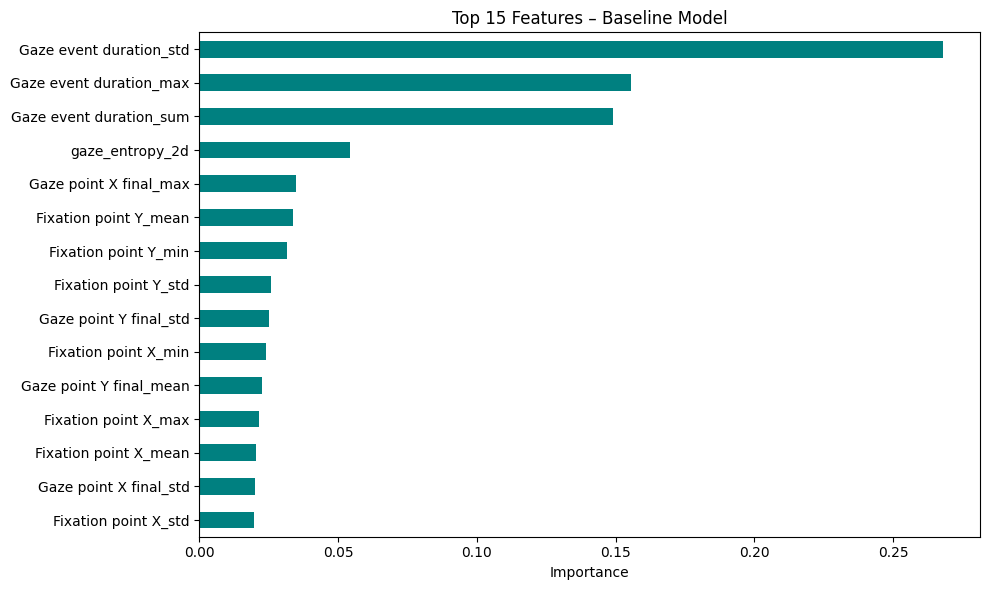

Selected top features: ['Gaze event duration_std', 'Gaze event duration_max', 'Gaze event duration_sum', 'gaze_entropy_2d', 'Gaze point X final_max', 'Fixation point Y_mean', 'Fixation point Y_min', 'Fixation point Y_std', 'Gaze point Y final_std', 'Fixation point X_min', 'Gaze point Y final_mean', 'Fixation point X_max']


In [13]:
# Cell 5 – Feature selection (use only top 10–12 features)

print("Feature importance (baseline model):")
imp_base = pd.Series(rf_base.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_base.head(15).plot(kind='barh', color='teal')
plt.title("Top 15 Features – Baseline Model")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ❗ Remove duration again if selected by importance
top_features = [
    f for f in top_features
    if f != 'Gaze event duration_mean'
]

# Select top 12
top_features = imp_base.head(12).index.tolist()
print("Selected top features:", top_features)

X_reduced = X[top_features]
X_train_red = X_train[top_features]
X_test_red  = X_test[top_features]

In [14]:
# Cell 6 – Tuned model on reduced features

param_grid = {
    'n_estimators': [150, 200, 250],
    'max_depth': [6, 8, 10],
    'min_samples_split': [8, 10],
    'min_samples_leaf': [3, 4],
    'max_features': ['sqrt']
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42,
                           class_weight='balanced',
                           n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV...")

# 🔥 IMPORTANT: fit only on training data
grid.fit(X_train_red, y_train)

print("\nBest parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_.round(4))

# Final model
best_rf = grid.best_estimator_

# Test on hold-out set
y_pred_best = best_rf.predict(X_test_red)
test_acc_best = accuracy_score(y_test, y_pred_best)

print(f"Final test accuracy: {test_acc_best:.4f}")
print("\nClassification report:\n",
      classification_report(y_test, y_pred_best))

Running GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 200}
Best CV accuracy: 0.791
Final test accuracy: 0.7000

Classification report:
               precision    recall  f1-score   support

        High       0.82      0.74      0.78        38
         Low       0.71      0.74      0.72        23
    Moderate       0.56      0.62      0.59        29

    accuracy                           0.70        90
   macro avg       0.70      0.70      0.70        90
weighted avg       0.71      0.70      0.70        90



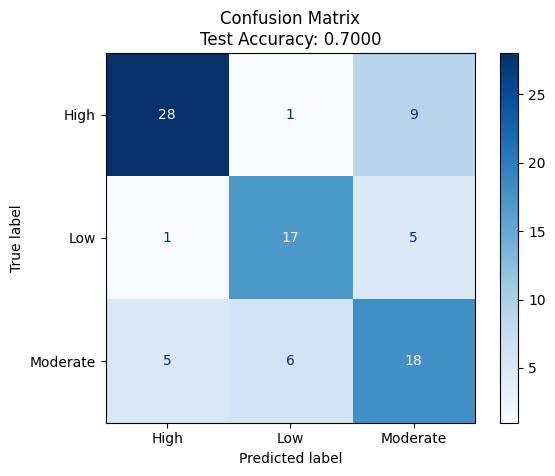

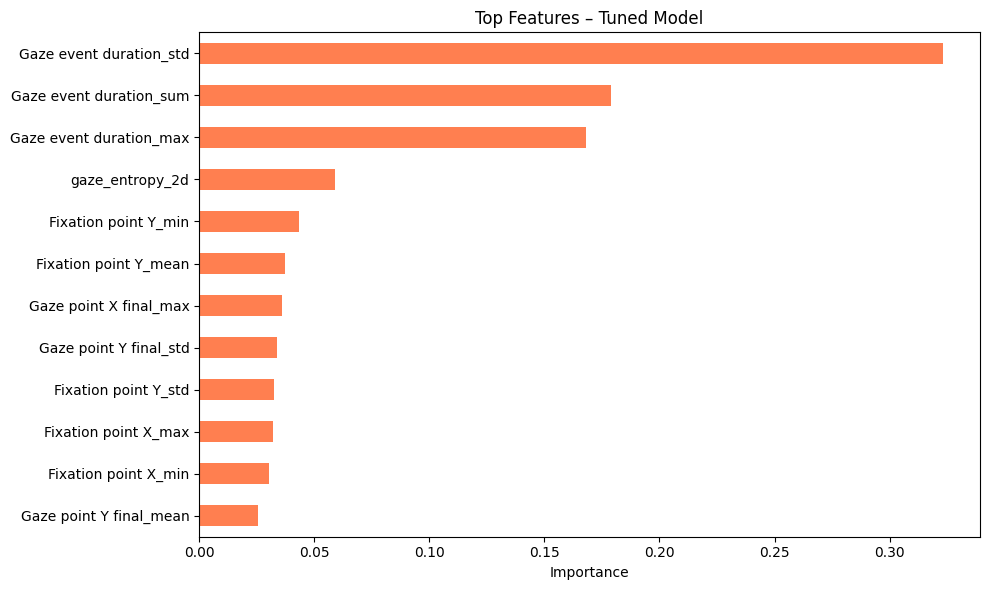

In [15]:
# Cell 7 – Visualizations

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(cm, display_labels=best_rf.classes_)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix\nTest Accuracy: {test_acc_best:.4f}")
plt.show()

# Feature importance of best model
imp_final = pd.Series(best_rf.feature_importances_, index=top_features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp_final.plot(kind='barh', color='coral')
plt.title("Top Features – Tuned Model")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
# Cell 8 – Save best model & results

joblib.dump(best_rf, MODEL_SAVE)
print(f"Best model saved: {MODEL_SAVE}")

# Optional: save predictions
results = pd.DataFrame({
    'true': y_test,
    'predicted': y_pred_best
})
results.to_csv(r"D:\emotion-drift-project\data\test_predictions.csv", index=False)
print("Test predictions saved.")

Best model saved: D:\emotion-drift-project\data\rf_model_best.joblib
Test predictions saved.


In [17]:
# Quick re-run with slightly deeper trees

rf_final = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=8,
    min_samples_leaf=3,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

cv_scores_final = cross_val_score(
    rf_final,
    X_train_red,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

print(f"Updated CV accuracy: {cv_scores_final.mean():.4f} ± {cv_scores_final.std():.4f}")

Updated CV accuracy: 0.7762 ± 0.0612


In [19]:
import pandas as pd
import numpy as np
import joblib
from scipy.spatial.distance import pdist
from scipy.stats import entropy
MODEL_PATH = r"D:\emotion-drift-project\data\rf_model_best.joblib"
model = joblib.load(MODEL_PATH)
print("Model loaded successfully!\n")
sample_data = pd.DataFrame({
    'Gaze point X final': [500, 501, 499, 500, 502, 498, 500],
    'Gaze point Y final': [400, 399, 401, 400, 398, 402, 400],
    'Gaze event duration': [320, 340, 330, 310, 350, 325, 315]
})
print("Sample trial data:")
print(sample_data)
features = {}
features['Gaze point X final_mean'] = sample_data['Gaze point X final'].mean()
features['Gaze point X final_std']  = sample_data['Gaze point X final'].std()
features['Gaze point Y final_mean'] = sample_data['Gaze point Y final'].mean()
features['Gaze point Y final_std']  = sample_data['Gaze point Y final'].std()

features['Gaze event duration_mean'] = sample_data['Gaze event duration'].mean()
features['Gaze event duration_std']  = sample_data['Gaze event duration'].std()
features['Gaze event duration_sum']  = sample_data['Gaze event duration'].sum()
features['Gaze event duration_max']  = sample_data['Gaze event duration'].max()

coords = sample_data[['Gaze point X final', 'Gaze point Y final']]
features['gaze_dispersion_mean'] = pdist(coords).mean()

hist, _, _ = np.histogram2d(
    sample_data['Gaze point X final'],
    sample_data['Gaze point Y final'],
    bins=10
)
hist = hist / hist.sum()
features['gaze_entropy_2d'] = entropy(hist.flatten() + 1e-10)

features_df = pd.DataFrame([features])

print("\nCalculated features:")
print(features_df)

if hasattr(model, 'feature_names_in_'):
    expected_features = list(model.feature_names_in_)
else:
    expected_features = features_df.columns.tolist()

for f in expected_features:
    if f not in features_df.columns:
        features_df[f] = 0.0

features_df = features_df[expected_features]

features_df = features_df.apply(pd.to_numeric, errors='coerce').fillna(0.0)

print("\nAligned feature vector:")
print(features_df)

prediction = model.predict(features_df)[0]

print("\nPredicted Gaze Behavior Level:")
print("Predicted Output:", prediction)

Model loaded successfully!

Sample trial data:
   Gaze point X final  Gaze point Y final  Gaze event duration
0                 500                 400                  320
1                 501                 399                  340
2                 499                 401                  330
3                 500                 400                  310
4                 502                 398                  350
5                 498                 402                  325
6                 500                 400                  315

Calculated features:
   Gaze point X final_mean  Gaze point X final_std  Gaze point Y final_mean  \
0                    500.0                1.290994                    400.0   

   Gaze point Y final_std  Gaze event duration_mean  Gaze event duration_std  \
0                1.290994                327.142857                14.099983   

   Gaze event duration_sum  Gaze event duration_max  gaze_dispersion_mean  \
0                     2290    